# Section 7: R - Clustering and Visualization

    • Dataset Specifications: Regional sales data with columns: Region (e.g., North, South, East, West), Quantity (integer), Revenue (float); ~500 rows; supports k-means clustering and visualization.  
    • Tasks:  
        1. Perform k-means clustering to group regions based on revenue and quantity sold. Visualize the clusters using a scatter plot. 
    • Output: R script file (.R) and visualization (e.g., scatter plot of clusters).  
    • Interpretation: In 100-150 words, explain the clustering results and their potential for targeted marketing strategies. 

In [6]:
# Load libraries
library(ggplot2)
library(dplyr)

In [7]:
# Load data
sales <- read.csv("sales_data.csv")

# Check structure
str(sales)

'data.frame':	1000 obs. of  14 variables:
 $ Product_ID          : int  1052 1093 1015 1072 1061 1021 1083 1087 1075 1075 ...
 $ Sale_Date           : chr  "2023-02-03" "2023-04-21" "2023-09-21" "2023-08-24" ...
 $ Sales_Rep           : chr  "Bob" "Bob" "David" "Bob" ...
 $ Region              : chr  "North" "West" "South" "South" ...
 $ Sales_Amount        : num  5054 4384 4631 2168 3750 ...
 $ Quantity_Sold       : int  18 17 30 39 13 32 29 46 30 18 ...
 $ Product_Category    : chr  "Furniture" "Furniture" "Food" "Clothing" ...
 $ Unit_Cost           : num  153 3816 262 4330 637 ...
 $ Unit_Price          : num  267 4209 371 4468 693 ...
 $ Customer_Type       : chr  "Returning" "Returning" "Returning" "New" ...
 $ Discount            : num  0.09 0.11 0.2 0.02 0.08 0.21 0.14 0.12 0.05 0.13 ...
 $ Payment_Method      : chr  "Cash" "Cash" "Bank Transfer" "Credit Card" ...
 $ Sales_Channel       : chr  "Online" "Retail" "Retail" "Retail" ...
 $ Region_and_Sales_Rep: chr  "North-Bob" "We

In [8]:
# Summarize by Region
region_summary <- sales %>%
  group_by(Region) %>%
  summarise(
    Total_Quantity = sum(Quantity_Sold),
    Total_Revenue = sum(Sales_Amount)
  )

str(region_summary)

tibble [4 × 3] (S3: tbl_df/tbl/data.frame)
 $ Region        : chr [1:4] "East" "North" "South" "West"
 $ Total_Quantity: int [1:4] 6356 6705 5808 6486
 $ Total_Revenue : num [1:4] 1259793 1369613 1154251 1235609


In [9]:
# Scale for clustering
scaled_data <- scale(region_summary[, c("Total_Quantity", "Total_Revenue")])

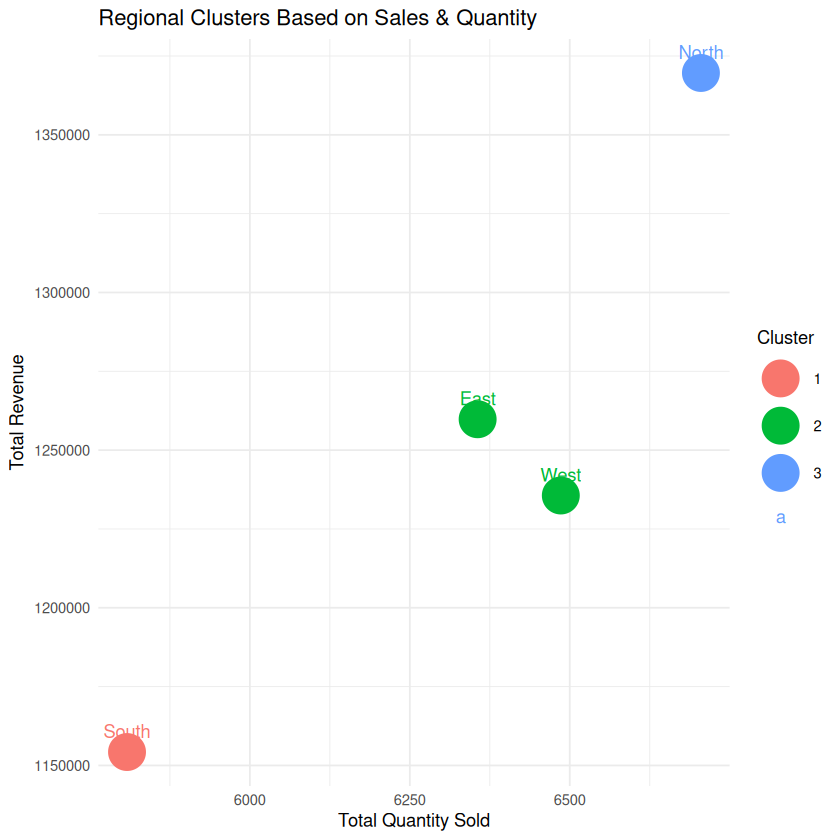

In [10]:
# Apply k-means
set.seed(123)
kmeans_result <- kmeans(scaled_data, centers = 3)

# Add cluster labels
region_summary$Cluster <- as.factor(kmeans_result$cluster)

# Visualize
ggplot(region_summary, aes(x = Total_Quantity, y = Total_Revenue, color = Cluster)) +
  geom_point(size = 10) +
  geom_text(aes(label = Region), vjust = -1) +
  theme_minimal() +
  labs(title = "Regional Clusters Based on Sales & Quantity",
       x = "Total Quantity Sold",
       y = "Total Revenue")

In [11]:
ggsave("clusters_plot.png")

Saving 7 x 7 in image
